### **Dự Báo Phụ Tải Điều Độ**

In [ ]:
!pip install tensorflow


In [ ]:
# @title Tải thư viện
import tensorflow as tf
from tensorflow import keras
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import backend as K
from sklearn import preprocessing

In [ ]:
# @title Tải dữ liệu
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

file_path = '/content/drive/My Drive/Code-1/Thực tập 1-Dự báo phụ tải/Đề tài/du_lieu_phu_tai.csv'
df = pd.read_csv(file_path)
df.head()

Mounted at /content/drive


,thoiGian,congSuatMB,congSuatMT,congSuatMN,congSuatHT,ngay,Da_Nang_nhietDo,Hanoi_nhietDo,Ho_Chi_Minh_City_nhietDo,Da_Nang_doAm,Hanoi_doAm,Ho_Chi_Minh_City_doAm
0,1/1/2023 0:30,8893.5,2133.8,9313.8,20341.1,1/1/2023,20.4,11.15,23.20,80.0,76.0,66.0
1,1/1/2023 1:00,9321.5,2081.3,9122.3,20525.1,1/1/2023,20.2,10.90,22.90,82.0,77.0,67.0
2,1/1/2023 1:30,8674.0,2088.3,8895.7,19658.0,1/1/2023,19.9,10.80,22.65,84.0,77.5,68.5
3,1/1/2023 2:00,8435.8,2107.1,8839.7,19382.6,1/1/2023,19.6,10.70,22.40,86.0,78.0,70.0
4,1/1/2023 2:30,8302.3,2121.4,8927.6,19351.3,1/1/2023,19.6,10.70,22.15,85.5,77.5,71.5


In [ ]:
df.drop(["thoiGian","congSuatHT","ngay"],axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39814 entries, 0 to 39813
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   congSuatMB                39814 non-null  float64
 1   congSuatMT                39814 non-null  float64
 2   congSuatMN                39814 non-null  float64
 3   Da_Nang_nhietDo           39814 non-null  float64
 4   Hanoi_nhietDo             39814 non-null  float64
 5   Ho_Chi_Minh_City_nhietDo  39814 non-null  float64
 6   Da_Nang_doAm              39814 non-null  float64
 7   Hanoi_doAm                39814 non-null  float64
 8   Ho_Chi_Minh_City_doAm     39814 non-null  float64
dtypes: float64(9)
memory usage: 2.7 MB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
congSuatMB,39814.0,15713.284971,3024.195902,0.0,13657.7750,15781.80,17741.925,26239.7
congSuatMT,39814.0,3336.116516,655.725949,0.0,2866.2000,3333.65,3806.000,5973.2
congSuatMN,39814.0,14832.788562,2665.287691,0.0,13005.9045,14970.90,16821.300,22670.7
Da_Nang_nhietDo,39814.0,25.989602,3.993904,15.0,23.1000,25.80,28.450,40.0
Hanoi_nhietDo,39814.0,23.798786,5.643238,6.6,19.8000,24.70,27.850,40.1
Ho_Chi_Minh_City_nhietDo,39814.0,27.711880,2.977413,19.6,25.5000,27.00,29.700,38.9
Da_Nang_doAm,39814.0,81.869757,12.027419,32.0,76.0000,85.00,91.000,100.0
Hanoi_doAm,39814.0,78.034623,15.207273,21.0,68.0000,80.50,91.000,100.0
Ho_Chi_Minh_City_doAm,39814.0,77.233687,15.593373,23.0,68.0000,81.00,90.000,100.0


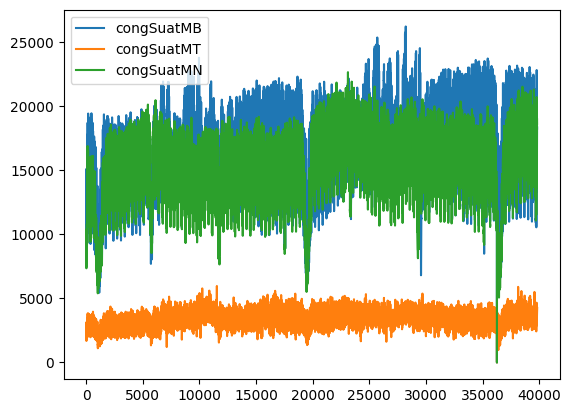

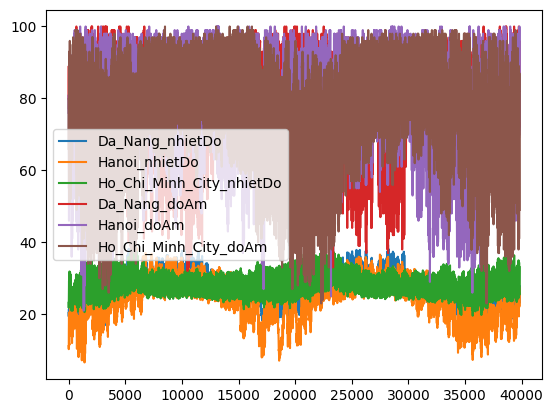

In [ ]:
wanted_column = ["congSuatMB",	"congSuatMT",	"congSuatMN" ]
df[wanted_column].plot(kind='line')
plt.show()

wanted_column2 = ["Da_Nang_nhietDo",	"Hanoi_nhietDo",	"Ho_Chi_Minh_City_nhietDo",	"Da_Nang_doAm",	"Hanoi_doAm",	"Ho_Chi_Minh_City_doAm"]
df[wanted_column2].plot(kind='line')
plt.show()

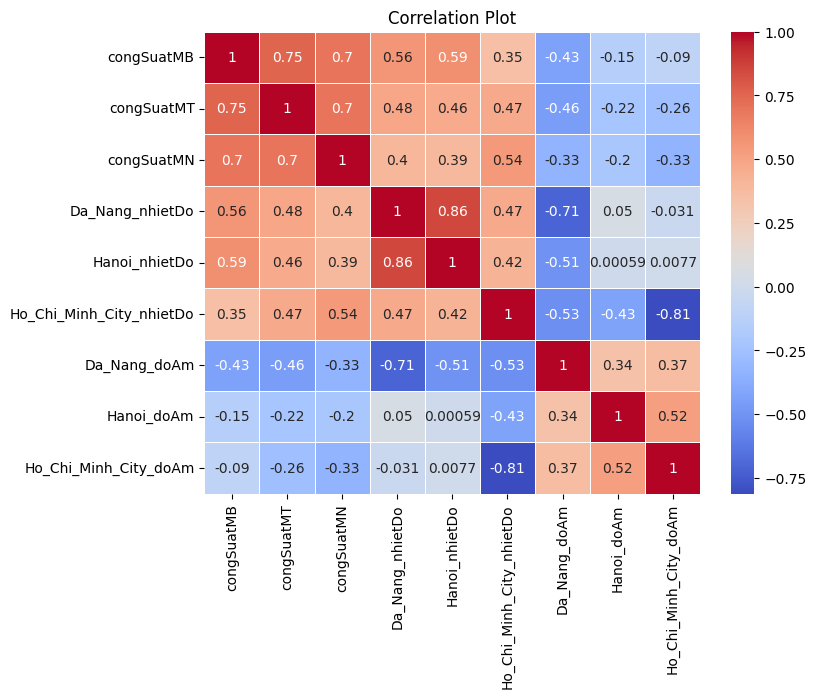

In [ ]:
# @title Biểu đồ tương quan

correlation_matrix = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Plot')
plt.show()


In [ ]:
# @title Chia tập huấn luyện, kiểm thử và kiểm tra. (0.8, 0.1, 0.1)
#df.drop(["Datetime","Humidity","WindSpeed","GeneralDiffuseFlows","DiffuseFlows"],axis=1,inplace=True)
percentage = 0.8
splitting_time = int(len(df) * percentage)
splitting_time2 = int(len(df)*0.1)

train_x = np.array(df.values[:splitting_time],dtype=np.float32)
val_x = np.array(df.values[splitting_time:splitting_time + splitting_time2],dtype=np.float32)
test_x = np.array(df.values[splitting_time + splitting_time2:],dtype=np.float32)

print("train dataset size : %d" %len(train_x))
print("validation dataset size : %d" %len(val_x))
print("test dataset size : %d" %len(test_x))

train dataset size : 31851
validation dataset size : 3981
test dataset size : 3982


In [ ]:
# @title Chuẩn hoá dữ liệu
# Construction of the series

train_x = tf.convert_to_tensor(train_x)
val_x = tf.convert_to_tensor(val_x)
test_x = tf.convert_to_tensor(test_x)

scaler = preprocessing.MinMaxScaler()
scaler.fit(train_x)

# Lưu scaler vào file
import os
import joblib

# Kiểm tra sự tồn tại của file scaler.pkl
if not os.path.exists('/content/drive/My Drive/Code-1/Thực tập 1-Dự báo phụ tải/Đề tài/scaler.pkl'):
    # Nếu file chưa tồn tại, lưu scaler vào file
    joblib.dump(scaler, '/content/drive/My Drive/Code-1/Thực tập 1-Dự báo phụ tải/Đề tài/scaler.pkl')
    print("Đã lưu scaler vào file 'scaler.pkl'.")
else:
    # Nếu file đã tồn tại, không lưu lại
    print("File 'scaler.pkl' đã tồn tại, không cần lưu lại.")

File 'scaler.pkl' đã tồn tại, không cần lưu lại.


In [ ]:
import joblib

# Tải scaler từ file
scaler = joblib.load('/content/drive/My Drive/Code-1/Thực tập 1-Dự báo phụ tải/Đề tài/scaler.pkl')

# Sử dụng scaler để chuẩn hóa dữ liệu
train_x_norm = scaler.transform(train_x)
val_x_norm = scaler.transform(val_x)
test_x_norm = scaler.transform(test_x)

print("train_x_norm: ",train_x_norm.shape)
print(train_x_norm);print()

print("val_x_norm: ",val_x_norm.shape)
print(val_x_norm);print()

print("test_x_norm: ",test_x_norm.shape)
print(test_x_norm);print()

train_x_norm:  (31851, 9)
[[0.16571517 0.21048736 0.22657023 ... 0.70588235 0.69620253 0.55844156]
 [0.18630031 0.19969156 0.21548145 ... 0.73529412 0.70886076 0.57142857]
 [0.15515807 0.201131   0.20236022 ... 0.76470588 0.71518987 0.59090909]
 ...
 [0.47489627 0.43855641 0.66419802 ... 0.43382353 0.2278481  0.51298701]
 [0.48987821 0.43756941 0.72632996 ... 0.42647059 0.2278481  0.48051948]
 [0.52792703 0.4685585  0.77077773 ... 0.41176471 0.2278481  0.46753247]]

val_x_norm:  (3981, 9)
[[0.55969931 0.49790251 0.75633623 ... 0.39705882 0.2278481  0.45454545]
 [0.58309328 0.5372198  0.76499301 ... 0.41176471 0.22151899 0.45454545]
 [0.59404472 0.56092945 0.77025659 ... 0.42647059 0.21518987 0.45454545]
 ...
 [0.5649462  0.59191422 0.60880193 ... 0.66176471 0.24050633 0.54545455]
 [0.52513266 0.54005139 0.60012982 ... 0.63235294 0.2278481  0.51948052]
 [0.47428624 0.54200737 0.57263015 ... 0.60294118 0.21518987 0.49350649]]

test_x_norm:  (3982, 9)
[[0.44626893 0.51555353 0.59579204 ..

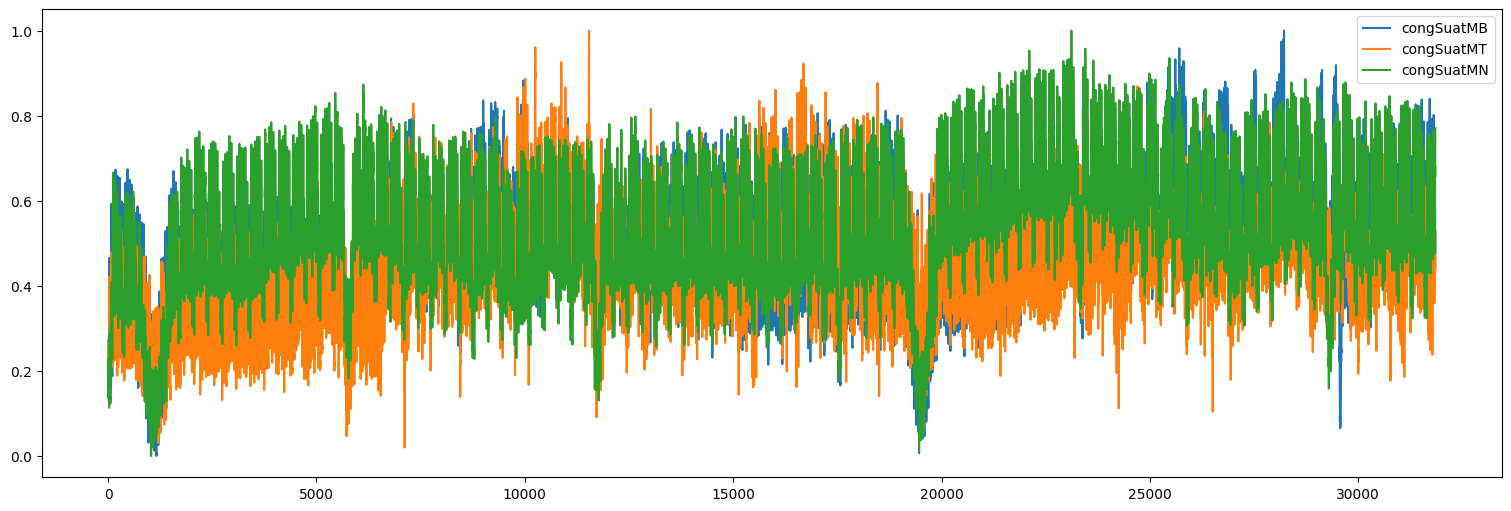

In [ ]:
# @title Trực quan hoá 1

# Displaying some scaled series
cols = list(df.columns)

fig, ax = plt.subplots(constrained_layout=True, figsize=(15,5))
for i in range(3):
  ax.plot(df.index[:splitting_time].values,train_x_norm[:,i], label= cols[i])
ax.legend()
plt.show()

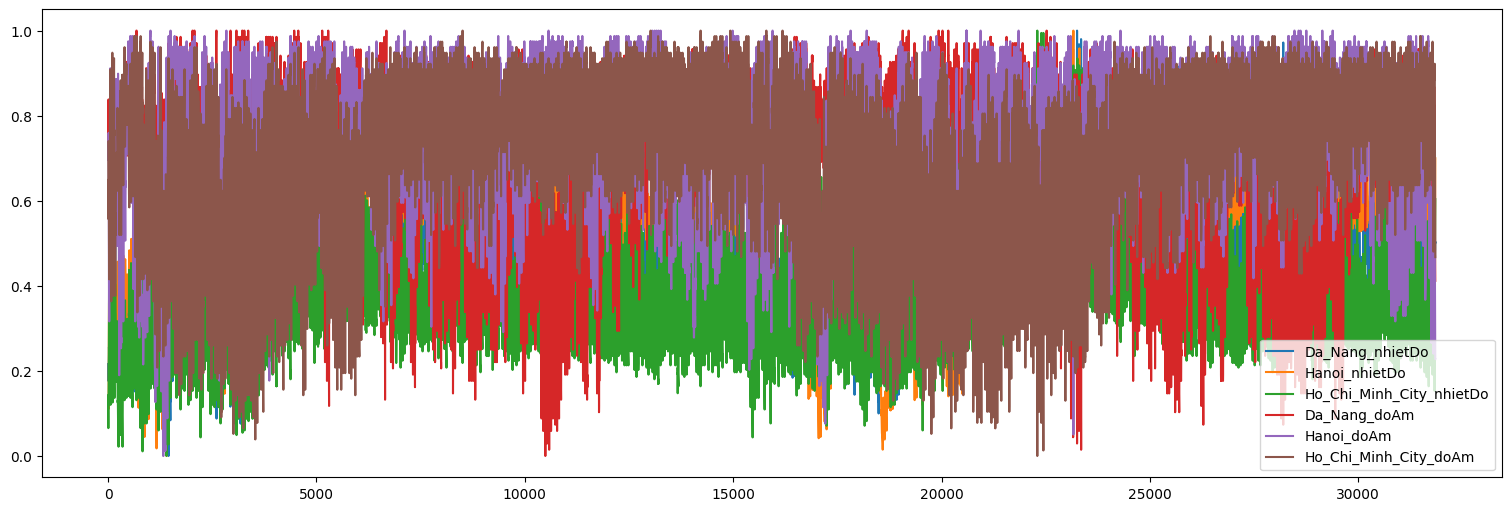

In [ ]:
# @title Trực quan hoá 2
fig, ax = plt.subplots(constrained_layout=True, figsize=(15,5))
for i in range(3,9):
  ax.plot(df.index[:splitting_time].values,train_x_norm[:,i], label= cols[i])
ax.legend()
plt.show()


In [ ]:
'''
from tensorflow.keras.layers import Lambda

# @title Định nghĩa mô hình (không dùng)
def model_wavenet_timeseries(len_seq, len_out, dim_exo, nb_filters, dim_filters, dilation_depth, use_bias, res_l2, final_l2,batch_size):
  input_shape_exo = tf.keras.Input(shape=(len_seq, dim_exo), name='input_exo')
  input_shape_target = tf.keras.Input(shape=(len_seq, 3), name='input_target')

  input_exo = input_shape_exo
  input_target = input_shape_target

  outputs = []

  # 1st loop: I'll be making multi-step predictions (every prediction will serve as input for the second prediction, when I move the window size...).
  for t in range(len_out):

    # Causal convolution for the 1st input: exogenous series
    # out_exo : (batch_size,len_seq,dim_exo)
    out_exo = Lambda(lambda x: K.temporal_padding(x, padding=((dim_filters - 1), 0)),
                     output_shape=lambda s: (s[0], s[1] + (dim_filters - 1), s[2]))(input_exo)
    out_exo = tf.keras.layers.Conv1D(filters=nb_filters, kernel_size=dim_filters,dilation_rate=1,use_bias=use_bias,activation=None,
                              name='causal_convolution_exo_%i' %t, kernel_regularizer=tf.keras.regularizers.l2(res_l2))(out_exo)

    # Causal convolution for the 2nd input: target series
    # out_target : (batch_size,len_seq,1)
    out_target = Lambda(lambda x: K.temporal_padding(x, padding=((dim_filters - 1), 0)),
                        output_shape=lambda s: (s[0], s[1] + (dim_filters - 1), s[2]))(input_target)
    out_target = tf.keras.layers.Conv1D(filters=nb_filters, kernel_size=dim_filters,dilation_rate=1,use_bias=use_bias,activation=None,
                              name='causal_convolution_target_%i' %t, kernel_regularizer=tf.keras.regularizers.l2(res_l2))(out_target)

    # Frist Layer #1 (See visual Above)
    # Dilated Convolution (1st Layer #1): part of exogenous series(see visual above)
    # skip_exo : (batch_size,len_seq,dim_exo)
    # first_out_exo (the same as skip_exo, before adding the residual connection): (batch_size, len_seq, dim_exo)
    skip_outputs = []
    z_exo = Lambda(lambda x: K.temporal_padding(x, padding=(2*(dim_filters - 1), 0)),
                   output_shape=lambda s: (s[0], s[1] + 2*(dim_filters - 1), s[2]))(out_exo)
    z_exo = tf.keras.layers.Conv1D(filters=nb_filters,kernel_size=dim_filters,dilation_rate=2,use_bias=use_bias,activation="relu",
                              name='dilated_convolution_exo_1_%i' %t, kernel_regularizer=tf.keras.regularizers.l2(res_l2))(z_exo)
    skip_exo = tf.keras.layers.Conv1D(dim_exo, 1, padding='same', use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(res_l2))(z_exo)
    first_out_exo = tf.keras.layers.Conv1D(dim_exo, 1, padding='same', use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(res_l2))(z_exo)

    # Dilated Convolution (1st Layer #1): part of target series(see visual above)
    # skip_target : (batch_size,len_seq,1)
    # first_out_target (the same as skip_target, before adding the residual connection): (batch_size, len_seq,1)
    z_target = Lambda(lambda x: K.temporal_padding(x, padding=(2*(dim_filters - 1), 0)),
                      output_shape=lambda s: (s[0], s[1] + 2*(dim_filters - 1), s[2]))(out_target)
    z_target = tf.keras.layers.Conv1D(filters=nb_filters,kernel_size=dim_filters,dilation_rate=2,use_bias=use_bias,activation="relu",
                              name='dilated_convolution_target_1_%i' %t, kernel_regularizer=tf.keras.regularizers.l2(res_l2))(z_target)
    skip_target = tf.keras.layers.Conv1D(1, 1, padding='same', use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(res_l2))(z_target)
    first_out_target = tf.keras.layers.Conv1D(1, 1, padding='same', use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(res_l2))(z_target)

    # Concatenation of the skip_exo & skip_target AND Saving them as we go through the 1st for loop (through len_seq)
    # skip_exo : (batch_size,len_seq,dim_exo)
    # skip_target : (batch_size,len_seq,1)
    # The concatenation of skip_exo & skip_target : (batch_size,len_seq,dim_exo+1)
    concat_skip = Lambda(lambda x: tf.concat(x, axis=2),
                         output_shape=lambda s: (s[0][0], s[0][1], s[0][2] + s[1][2]))([skip_exo, skip_target])
    skip_outputs.append(concat_skip)

    # Adding the Residual connections of the exogenous series & target series to inputs
    # res_exo_out : (batch_size,len_seq,dim_exo)
    # res_target_out : (batch_size,len_seq,1)
    res_exo_out = tf.keras.layers.Add()([input_exo, first_out_exo])
    res_target_out = tf.keras.layers.Add()([input_target, first_out_target])

    # Concatenation of the updated outputs (after having added the residual connections)
    # out_concat : (batch_size,len_seq,dim_exo+1)
    out_concat = Lambda(lambda x: tf.concat(x, axis=2),
                        output_shape=lambda s: (s[0][0], s[0][1], s[0][2] + s[1][2]))([res_exo_out, res_target_out])
    out = out_concat

    # From 2nd Layer Layer#2 to Final Layer (Layer #L): See Visual above
    # 2nd loop: inner loop (Going through all the intermediate layers)
    # Intermediate dilated convolutions
    for i in range(2, dilation_depth + 1):
      pad_amount = 2**i * (dim_filters - 1)
      z = Lambda(lambda x, pad=pad_amount: K.temporal_padding(x, padding=(pad, 0)),
                 output_shape=lambda s, pad=pad_amount: (s[0], s[1] + pad, s[2]))(out_concat)
      z = tf.keras.layers.Conv1D(filters=nb_filters,kernel_size=dim_filters,dilation_rate=2**i,use_bias=use_bias,activation="relu",
                              name='dilated_convolution_%i_%i' %(i,t), kernel_regularizer=tf.keras.regularizers.l2(res_l2))(z)

      skip_x = tf.keras.layers.Conv1D(dim_exo+1, 1, padding='same', use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(res_l2))(z)
      first_out_x = tf.keras.layers.Conv1D(dim_exo+1, 1, padding='same', use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(res_l2))(z)

      res_x = tf.keras.layers.Add()([out, first_out_x])  #(batch_size,len_seq,dim_exo+1)
      out = res_x
      skip_outputs.append(skip_x)

    # Adding intermediate outputs of all the layers (See Visual above)
    out = tf.keras.layers.Add()(skip_outputs)            #(batch_size,len_seq,dim_exo+1)

    # Output Layer (exogenous series & target series)
    # outputs : (batch_size,1,1) # The predcition Y
    # out_f_exo (will be used to Adjust the input for the following prediction, see below) : (batch_size,len_seq,dim_exo)
    out = tf.keras.layers.Activation('linear', name="output_linear_%i" %t)(out)
    out_f_target = tf.keras.layers.Conv1D(1, 1, padding='same', kernel_regularizer=tf.keras.regularizers.l2(final_l2))(out)
    out_f_exo = tf.keras.layers.Conv1D(dim_exo, 1, padding='same', kernel_regularizer=tf.keras.regularizers.l2(final_l2))(out)
    outputs.append(Lambda(lambda x: x[:, -1:, :], output_shape=lambda s: (s[0], 1, s[2]))(out_f_target))

    # Adjusting the entry of exogenous series,for the following prediction (of MultiStep predictions): see the 1st loop
    # First: concatenate the previous exogenous series input with the final exo_prediction(current exo_prediction)
    new_exo = Lambda(lambda x: tf.concat(x, axis=1),
                     output_shape=lambda s: (s[0][0], s[0][1] + s[1][1], s[0][2]))([
                         input_exo,
                         Lambda(lambda x: x[:, -1:, :], output_shape=lambda s: (s[0], 1, s[2]))(out_f_exo)
                     ])
    # Second, shift the moving window (of len_seq size) by one
    input_exo = Lambda(lambda x: x[:, 1:, :], output_shape=lambda s: (s[0], s[1]-1, s[2]))(new_exo)

    # Adjusting the entry of target series,for the following prediction (of MultiStep predictions): see the 1st loop
    # First: concatenate the previous target series input with the final prediction(current prediction)
    new_target = Lambda(lambda x: tf.concat(x, axis=1),
                        output_shape=lambda s: (s[0][0], s[0][1] + s[1][1], s[0][2]))([
                            input_target,
                            Lambda(lambda x: x[:, -1:, :], output_shape=lambda s: (s[0], 1, s[2]))(out_f_target)
                        ])
    # Second, shift the moving window (of len_seq size) by one
    input_target = Lambda(lambda x: x[:, 1:, :], output_shape=lambda s: (s[0], s[1]-1, s[2]))(new_target)

  # Chuyển đổi danh sách outputs thành tensor với kích thước (batch_size, len_out, 1)
  outputs = Lambda(lambda x: tf.transpose(tf.squeeze(tf.stack(x), axis=-1), perm=[1, 0, 2]),
                   output_shape=lambda s: (None, len_out, 1))(outputs)
  model = tf.keras.Model([input_shape_exo, input_shape_target], outputs)
  return model
  '''

In [ ]:
# @title Định nghĩa mô hình (dùng)
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras import backend as K

# Định nghĩa mô hình WaveNet cho dự báo đa mục tiêu
# len_seq: độ dài chuỗi đầu vào
def model_wavenet_timeseries(
    len_seq,
    len_out,
    dim_exo,
    dim_target,       # số kênh target (ví dụ 3)
    nb_filters,
    dim_filters,
    dilation_depth,
    use_bias,
    res_l2,
    final_l2,
    batch_size

):
    # Input exogenous series
    input_exo = tf.keras.Input(shape=(len_seq, dim_exo), name='input_exo')
    # Input multi-target series
    input_target = tf.keras.Input(shape=(len_seq, dim_target), name='input_target')

    outputs = []
    # Khởi tạo 2 biến sẽ cập nhật cho từng bước dự báo
    exo_inp = input_exo
    tgt_inp = input_target

    for t in range(len_out):
        # --- Causal Convolution cho exogenous ---
        pad_exo = layers.Lambda(
            lambda x: K.temporal_padding(x, padding=((dim_filters - 1), 0)),
            output_shape=lambda s: (s[0], s[1] + dim_filters - 1, s[2])
        )(exo_inp)
        conv_exo = layers.Conv1D(
            filters=nb_filters,
            kernel_size=dim_filters,
            dilation_rate=1,
            use_bias=use_bias,
            activation=None,
            kernel_regularizer=regularizers.l2(res_l2),
            name=f'causal_conv_exo_{t}'
        )(pad_exo)

        # --- Causal Convolution cho target ---
        pad_tgt = layers.Lambda(
            lambda x: K.temporal_padding(x, padding=((dim_filters - 1), 0)),
            output_shape=lambda s: (s[0], s[1] + dim_filters - 1, s[2])
        )(tgt_inp)
        conv_tgt = layers.Conv1D(
            filters=nb_filters,
            kernel_size=dim_filters,
            dilation_rate=1,
            use_bias=use_bias,
            activation=None,
            kernel_regularizer=regularizers.l2(res_l2),
            name=f'causal_conv_tgt_{t}'
        )(pad_tgt)

        skip_connections = []

        # --- Lớp dilated đầu tiên cho exogenous & target ---
        def dilated_block(x, filters_out, name_prefix):
            pad_amt = 2 * (dim_filters - 1)
            z = layers.Lambda(
                lambda y: K.temporal_padding(y, padding=(pad_amt, 0)),
                output_shape=lambda s: (s[0], s[1] + pad_amt, s[2])
            )(x)
            z = layers.Conv1D(
                filters=nb_filters,
                kernel_size=dim_filters,
                dilation_rate=2,
                activation='relu',
                use_bias=use_bias,
                kernel_regularizer=regularizers.l2(res_l2),
                name=f'{name_prefix}_dilated1'
            )(z)
            skip = layers.Conv1D(
                filters_out,
                kernel_size=1,
                padding='same',
                use_bias=False,
                kernel_regularizer=regularizers.l2(res_l2),
                name=f'{name_prefix}_skip1'
            )(z)
            res = layers.Conv1D(
                filters_out,
                kernel_size=1,
                padding='same',
                use_bias=False,
                kernel_regularizer=regularizers.l2(res_l2),
                name=f'{name_prefix}_res1'
            )(z)
            return skip, res

        skip_exo1, res_exo1 = dilated_block(conv_exo, dim_exo, f'exo_{t}')
        skip_tgt1, res_tgt1 = dilated_block(conv_tgt, dim_target, f'tgt_{t}')
        skip_connections += [layers.Concatenate(axis=-1)([skip_exo1, skip_tgt1])]

        # Cộng residual vào input
        exo_out = layers.Add()([exo_inp, res_exo1])
        tgt_out = layers.Add()([tgt_inp, res_tgt1])

        # Kết hợp exo & target
        out = layers.Concatenate(axis=-1)([exo_out, tgt_out])

        # --- Các lớp dilated tiếp theo ---
        for i in range(2, dilation_depth + 1):
            pad_amt = (2 ** i) * (dim_filters - 1)
            z = layers.Lambda(
                lambda y, p=pad_amt: K.temporal_padding(y, padding=(p, 0)),
                output_shape=lambda s, p=pad_amt: (s[0], s[1] + p, s[2])
            )(out)
            z = layers.Conv1D(
                filters=nb_filters,
                kernel_size=dim_filters,
                dilation_rate=2 ** i,
                activation='relu',
                use_bias=use_bias,
                kernel_regularizer=regularizers.l2(res_l2),
                name=f'dilated_conv_{i}_{t}'
            )(z)
            skip_i = layers.Conv1D(
                dim_exo + dim_target,
                kernel_size=1,
                padding='same',
                use_bias=False,
                kernel_regularizer=regularizers.l2(res_l2),
                name=f'skip_{i}_{t}'
            )(z)
            res_i = layers.Conv1D(
                dim_exo + dim_target,
                kernel_size=1,
                padding='same',
                use_bias=False,
                kernel_regularizer=regularizers.l2(res_l2),
                name=f'res_{i}_{t}'
            )(z)
            out = layers.Add()([out, res_i])
            skip_connections.append(skip_i)

        # Tổng hợp skip connections
        total_skip = layers.Add(name=f'total_skip_{t}')(skip_connections)
        # Output linear
        lin = layers.Activation('linear', name=f'lin_out_{t}')(total_skip)

        # Tạo dự báo multi-target cho bước t
        out_f_tgt = layers.Conv1D(
            dim_target,
            kernel_size=1,
            padding='same',
            kernel_regularizer=regularizers.l2(final_l2),
            name=f'out_f_tgt_{t}'
        )(lin)
        # Lấy step prediction
        step_pred = layers.Lambda(
            lambda y: y[:, -1:, :],
            output_shape=lambda s: (s[0], 1, dim_target)
        )(out_f_tgt)
        outputs.append(step_pred)

        # Cập nhật input window cho bước tiếp theo
        # Exogenous
        new_exo = layers.Concatenate(axis=1)([
            exo_inp,
            layers.Lambda(lambda y: y[:, -1:, :])(layers.Conv1D(dim_exo,1,padding='same')(lin))
        ])
        exo_inp = layers.Lambda(lambda y: y[:, 1:, :])(new_exo)
        # Target
        new_tgt = layers.Concatenate(axis=1)([
            tgt_inp,
            step_pred
        ])
        tgt_inp = layers.Lambda(lambda y: y[:, 1:, :])(new_tgt)

    # Stack outputs thành (batch, len_out, dim_target)
    stacked = layers.Lambda(
        lambda xs: tf.concat(xs, axis=1),
        output_shape=lambda s: (None, len_out, dim_target)
    )(outputs)

    model = tf.keras.Model([input_exo, input_target], stacked)
    return model


In [ ]:
# @title Tạo mô hình

def compute_len_seq(dilation_depth):
  return (2 ** dilation_depth * 2)

nb_filters = 96
dim_filters = 2
dilation_depth = 4     # len_seq = 32
use_bias = True
res_l2 = 0
final_l2 = 0

batch_size = 128
len_out = 48
dim_exo = 6
dim_target = 3

len_seq = compute_len_seq(dilation_depth)
print(len_seq)

model = model_wavenet_timeseries(len_seq, len_out, dim_exo, dim_target, nb_filters, dim_filters, dilation_depth, use_bias, res_l2, final_l2, batch_size)
model.summary()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
'''
# @title Chuẩn bị dữ liệu huấn luyện
def transform_dataset(original_tensor, columns_to_remove):
  # Create new tensors by removing specified columns
  tensors = []
  for cols in columns_to_remove:
    remaining_cols = [i for i in range(original_tensor.shape[1]) if i not in cols]
    new_tensor = tf.concat([original_tensor[:, i:i+1] for i in remaining_cols], axis=1)
    tensors.append(new_tensor)

  # Create new columns with constant values
  for i, tensor in enumerate(tensors):
    constant_value = i + 1  # 1 for tensor1, 2 for tensor2, 3 for tensor3
    new_column = constant_value * tf.ones((original_tensor.shape[0], 1), dtype=original_tensor.dtype)
    tensors[i] = tf.concat([tensor, new_column], axis=1)

  # Concatenate all tensors along axis 0 to maintain the same number of columns
  transformed_tensor = tf.concat(tensors, axis=0)

  # Convert the last column to one-hot encoding
  num_classes = len(columns_to_remove)
  last_column = transformed_tensor[:, -1]
  one_hot_last_column = tf.one_hot(tf.cast(last_column, dtype=tf.int32), depth=num_classes, dtype=original_tensor.dtype)

  # Concatenate all columns except the last one with the one-hot encoded column
  transformed_tensor = tf.concat([transformed_tensor[:, :-1], one_hot_last_column], axis=1)

  # Move column 6 (index 5) to the last position
  column_6 = transformed_tensor[:, -4:-3]
  other_columns = tf.concat([transformed_tensor[:, :-4], transformed_tensor[:, -3:]], axis=1)
  transformed_tensor = tf.concat([other_columns, column_6], axis=1)

  return transformed_tensor
'''

# This is required for Model implementation (for more information, see the Model Architecture Above).

def prepare_dataset_XY(seriesx, seriesy, len_seq, len_out, batch_size,shift):
  '''
  A function for creating a dataset from time series data as follows:
  X = {((X1_1,X1_2,...,X1_T),(X2_1,X2_2,...,X2_T),(X3_1,X3_2,...,X3_T)),
       (Y1,Y2,...,YT)}
  Y = YT+1
  seriesx-- Exogenous series, shape: (Tin, number_of_exogenous_series) with Tin: length of the time series
  seriesy-- Target series, shape: (Tin, 1)
  len_seq-- Sequence length: integer
  len_out-- Length of the predicted sequence (output): integer
  shift-- The window offset: integer
  batch_size-- Size of the batch: integer

  '''
import tensorflow as tf
import numpy as np

def prepare_dataset_XY(full_series, len_seq, len_out, batch_size, shift):
  # Tách exogenous (6 cột cuối) và target (3 cột đầu)
  seriesx = full_series[:, 3:]  # shape (T, 6)
  seriesy = full_series[:, :3]  # shape (T, 3)

  # Exogenous series input (X1)
  dataset_x = tf.data.Dataset.from_tensor_slices(seriesx)
  dataset_x = dataset_x.window(len_seq + len_out, shift=shift, drop_remainder=True)
  dataset_x = dataset_x.flat_map(lambda x: x.batch(len_seq + len_out))
  dataset_x = dataset_x.map(lambda x: x[0:len_seq][:, :])
  dataset_x = dataset_x.batch(batch_size, drop_remainder=True).prefetch(1)

  # Target series input (X2)
  dataset_y = tf.data.Dataset.from_tensor_slices(seriesy)
  dataset_y = dataset_y.window(len_seq + len_out, shift=shift, drop_remainder=True)
  dataset_y = dataset_y.flat_map(lambda x: x.batch(len_seq + len_out))
  dataset_y = dataset_y.map(lambda x: x[0:len_seq][:, :])
  dataset_y = dataset_y.batch(batch_size, drop_remainder=True).prefetch(1)

  # Ground truth (y): lấy phần len_out tiếp theo của target
  dataset_ypred = tf.data.Dataset.from_tensor_slices(seriesy)
  dataset_ypred = dataset_ypred.window(len_seq + len_out + 1, shift=shift, drop_remainder=True)
  dataset_ypred = dataset_ypred.flat_map(lambda x: x.batch(len_seq + len_out + 1))
  dataset_ypred = dataset_ypred.map(lambda x: x[0:len_seq+1][-len_out:, :])
  dataset_ypred = dataset_ypred.batch(batch_size, drop_remainder=True).prefetch(1)

  dataset = tf.data.Dataset.zip((dataset_x, dataset_y))
  dataset = tf.data.Dataset.zip((dataset, dataset_ypred))
  return dataset


def reshape_and_combine(dataset):
  X1 = []
  X2 = []

  # Extracting x and y from the dataset
  x, y = zip(*dataset)
  for i in range(len(x)):
    X1.append(x[i][0])  # exogenous input
    X2.append(x[i][1])  # target input

  X1 = np.asarray(X1, dtype=np.float32)  # (xx, BS, len_seq, 6)
  X2 = np.asarray(X2, dtype=np.float32)  # (xx, BS, len_seq, 3)
  y = np.asarray(y, dtype=np.float32)    # (xx, BS, len_out, 3)

  # Reshape to merge batches
  X1_reshaped = np.reshape(X1, (X1.shape[0] * X1.shape[1], X1.shape[2], X1.shape[3]))
  X2_reshaped = np.reshape(X2, (X2.shape[0] * X2.shape[1], X2.shape[2], X2.shape[3]))
  y_reshaped  = np.reshape(y,  (y.shape[0]  * y.shape[1],  y.shape[2],  y.shape[3]))

  x_train = [X1_reshaped, X2_reshaped]
  y_train = y_reshaped
  return x_train, y_train

In [ ]:
# @title Không dùng
'''
train_x_norm = scaler.transform(train_x)
val_x_norm = scaler.transform(val_x)
test_x_norm = scaler.transform(test_x)

columns_to_remove = ([2, 3], [1, 3], [1, 2])

train_x_norm = transform_dataset(train_x_norm, columns_to_remove)
print("train_x_norm")
print(train_x_norm);print()

val_x_norm = transform_dataset(val_x_norm, columns_to_remove)
print("val_x_norm")
print(val_x_norm);print()

test_x_norm = transform_dataset(test_x_norm, columns_to_remove)
print("test_x_norm")
print(test_x_norm)
'''

In [ ]:
# The characteristics of the dataset I want to create

batch_size = 128
len_out = 18
len_seq = compute_len_seq(dilation_depth)
shift=1

# Dataset creation
# Dataset creation
dataset = prepare_dataset_XY(train_x_norm, len_seq, len_out, batch_size, shift)
dataset_val = prepare_dataset_XY(val_x_norm, len_seq, len_out, batch_size, shift)
dataset_test = prepare_dataset_XY(test_x_norm, len_seq, len_out, batch_size, shift)


In [ ]:
print(len(list(dataset.as_numpy_iterator())))
print(("---------------"))
for element in dataset.take(1):
  print(element[0][0].shape)
  print(element[0][1].shape)
  print(element[1].shape)

248
---------------
(128, 32, 6)
(128, 32, 3)
(128, 18, 3)


In [ ]:
print(len(list(dataset_val.as_numpy_iterator())))
print(("---------------"))
for element in dataset_val.take(1):
  print(element[0][0].shape)
  print(element[0][1].shape)
  print(element[1].shape)

30
---------------
(128, 32, 6)
(128, 32, 3)
(128, 18, 3)


In [ ]:
x_train, y_train = reshape_and_combine(dataset)
print("reshaped and combined train dataset")
print(x_train[0].shape)
print(x_train[1].shape)
print(y_train.shape);print()

print("reshaped and combined validation dataset")
x_val, y_val = reshape_and_combine(dataset_val)
print(x_val[0].shape)
print(x_val[1].shape)
print(y_val.shape);print()

print("reshaped and combined test dataset")
x_test, y_test = reshape_and_combine(dataset_test)
print(x_test[0].shape)
print(x_test[1].shape)
print(y_test.shape)

reshaped and combined train dataset
(31744, 32, 6)
(31744, 32, 3)
(31744, 18, 3)

reshaped and combined validation dataset
(3840, 32, 6)
(3840, 32, 3)
(3840, 18, 3)

reshaped and combined test dataset
(3840, 32, 6)
(3840, 32, 3)
(3840, 18, 3)


In [ ]:
# @title Cài đặt môi trường và huấn luyện
import tensorflow as tf

try:
  # Thử tìm TPU
  tpu = tf.distribute.cluster_resolver.TPUClusterResolver()  # Tìm TPU (nếu không có thì sẽ ném ValueError)
  tf.config.experimental_connect_to_cluster(tpu)
  tf.tpu.experimental.initialize_tpu_system(tpu)
  strategy = tf.distribute.experimental.TPUStrategy(tpu)
  print("Running on TPU:", tpu.master())
except ValueError:
  # Nếu không tìm thấy TPU, kiểm tra GPU
  gpus = tf.config.list_physical_devices('GPU')
  if gpus:
    strategy = tf.distribute.get_strategy()  # Mặc định strategy sẽ dùng GPU nếu có
    print("Running on GPU")
  else:
    strategy = tf.distribute.get_strategy()  # Nếu không có GPU, dùng CPU
    print("Running on CPU")


Running on GPU


In [ ]:
# @title Quy trình huấn luyện mới

import tensorflow as tf
import os
import pandas as pd

# ================== CÀI ĐẶT THAM SỐ ==================
max_periods = 1000
checkpoint_dir = "/content/drive/My Drive/Code-1/Thực tập 1-Dự báo phụ tải/Đề tài/checkpoints"
log_path = '/content/drive/My Drive/Code-1/Thực tập 1-Dự báo phụ tải/Đề tài/training.log'
checkpoint_path = os.path.join(checkpoint_dir, "model_checkpoint.keras")

# ================== THIẾT LẬP STRATEGY ==================
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver.connect()
    strategy = tf.distribute.TPUStrategy(tpu)
    print("Running on TPU:", tpu.master())
    global_batch_size = batch_size * strategy.num_replicas_in_sync
except ValueError:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        strategy = tf.distribute.MirroredStrategy()
        print(f"Running on {len(gpus)} GPU(s)")
        global_batch_size = batch_size
    else:
        strategy = tf.distribute.get_strategy()
        print("Running on CPU")
        global_batch_size = batch_size

# ================== KHỞI TẠO/KHÔI PHỤC MÔ HÌNH ==================
initial_epoch = 0
lr_schedule = None

if os.path.exists(checkpoint_path):
    with strategy.scope():
        model = tf.keras.models.load_model(checkpoint_path)
        print("Đã tải lại mô hình và optimizer từ checkpoint")

    # Xác định epoch tiếp theo từ log
    if os.path.exists(log_path):
        log_df = pd.read_csv(log_path)
        if not log_df.empty:
            initial_epoch = log_df['epoch'].iloc[-1] + 1
            print(f"Tiếp tục từ epoch {initial_epoch}")

            # Tính toán learning rate hiện tại
            current_step = model.optimizer.iterations.numpy()
            current_lr = model.optimizer.learning_rate(current_step).numpy()
            print(f"Learning rate hiện tại: {current_lr}")
else:
    with strategy.scope():
        model = model_wavenet_timeseries(len_seq,
                                         len_out,
                                         dim_exo,
                                         dim_target,
                                         nb_filters,
                                         dim_filters,
                                         dilation_depth,
                                         use_bias,
                                         res_l2,
                                         final_l2,
                                         batch_size)

        # Cấu hình learning rate schedule
        lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
            initial_learning_rate=0.005 * strategy.num_replicas_in_sync,
            decay_steps=50,
            decay_rate=0.01,
            staircase=True
        )
        opt = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
        model.compile(loss="mse", optimizer=opt, metrics=["mse"])
        print("Khởi tạo mô hình mới")

# ================== CALLBACKS ==================
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        save_weights_only=False,
        save_best_only=True,
        monitor="val_loss",
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(log_path, append=True),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        min_delta=0.00001,  # Thay đổi tối thiểu để coi là cải thiện
        restore_best_weights=True
    )
]

# ================== CHUẨN BỊ DỮ LIỆU (KHÔNG SHUFFLE) ==================
def create_dataset(x_data, y_data):
    """
    x_data[0]: array shape (N, len_seq, 6)  – 6 biến ngoại sinh
    x_data[1]: array shape (N, len_seq, 3)  – 3 biến target
    y_data:    array shape (N, len_out, 3)  – nhãn dự báo
    """
    dataset = tf.data.Dataset.from_tensor_slices((
        {
          "input_exo":   x_data[0],  # full 6 features
          "input_target": x_data[1]  # full 3 features
        },
        y_data
    ))
    return dataset.batch(global_batch_size, drop_remainder=True)

# Tạo dataset cho huấn luyện và validation
train_dataset = create_dataset(x_train, y_train)
val_dataset   = create_dataset(x_val,   y_val)

# ================== HUẤN LUYỆN ==================
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=max_periods,
    initial_epoch=initial_epoch,
    callbacks=callbacks,
    verbose=1
)

print("Huấn luyện hoàn tất!")

Running on 1 GPU(s)
Khởi tạo mô hình mới
Epoch 1/1000
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - loss: 1.1850 - mse: 1.1850
Epoch 1: val_loss improved from inf to 0.01200, saving model to /content/drive/My Drive/Code-1/Thực tập 1-Dự báo phụ tải/Đề tài/checkpoints/model_checkpoint.keras
248/248 ━━━━━━━━━━━━━━━━━━━━ 104s 209ms/step - loss: 1.1819 - mse: 1.1819 - val_loss: 0.0120 - val_mse: 0.0120
Epoch 2/1000
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - loss: 0.0103 - mse: 0.0103
Epoch 2: val_loss improved from 0.01200 to 0.00696, saving model to /content/drive/My Drive/Code-1/Thực tập 1-Dự báo phụ tải/Đề tài/checkpoints/model_checkpoint.keras
248/248 ━━━━━━━━━━━━━━━━━━━━ 45s 180ms/step - loss: 0.0102 - mse: 0.0102 - val_loss: 0.0070 - val_mse: 0.0070
Epoch 3/1000
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - loss: 0.0065 - mse: 0.0065
Epoch 3: val_loss improved from 0.00696 to 0.00515, saving model to /content/drive/My Drive/Code-1/Thực tập 1-Dự báo phụ tải/Đề tài/checkpoints/model_che

In [ ]:
```python
import tensorflow as tf
import os
import pandas as pd

# ================== CÀI ĐẶT THAM SỐ ==================
max_periods = 1000
checkpoint_dir = "/content/drive/My Drive/Code-1/Thực tập 1-Dự báo phụ tải/Đề tài/checkpoints"
backup_dir = "/content/drive/My Drive/Code-1/Thực tập 1-Dự báo phụ tải/Đề tài/backup"
log_path = "/content/drive/My Drive/Code-1/Thực tập 1-Dự báo phụ tải/Đề tài/training.log"

# ================== THIẾT LẬP STRATEGY ==================
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver.connect()
    strategy = tf.distribute.TPUStrategy(tpu)
    print("Running on TPU:", tpu.master())
    global_batch_size = batch_size * strategy.num_replicas_in_sync
except ValueError:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        strategy = tf.distribute.MirroredStrategy()
        print(f"Running on {len(gpus)} GPU(s)")
        global_batch_size = batch_size
    else:
        strategy = tf.distribute.get_strategy()
        print("Running on CPU")
        global_batch_size = batch_size

# ================== KHỞI TẠO MÔ HÌNH ==================
with strategy.scope():
    model = model_wavenet_timeseries(
        len_seq, len_out, dim_exo, dim_target,
        nb_filters, dim_filters, dilation_depth,
        use_bias, res_l2, final_l2, batch_size
    )
    lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
        initial_learning_rate=0.005 * strategy.num_replicas_in_sync,
        decay_steps=50,
        decay_rate=0.01,
        staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    model.compile(loss='mse', optimizer=optimizer, metrics=['mse'])

# ================== CALLBACKS ==================
callbacks = [
    # Tự động backup trạng thái training khi gián đoạn
    tf.keras.callbacks.BackupAndRestore(backup_dir=backup_dir),

    # Chỉ lưu weights tốt nhất (theo val_loss) dưới dạng .hdf5
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(checkpoint_dir, 'best_model.hdf5'),
        save_weights_only=True,
        save_best_only=True,
        monitor='val_loss',
        mode='min',
        verbose=1
    ),

    # Ghi log huấn luyện (append tiếp)
    tf.keras.callbacks.CSVLogger(log_path, append=True),

    # Dừng sớm với restore best weights
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        min_delta=1e-5,
        restore_best_weights=True
    )
]

# ================== CHUẨN BỊ DỮ LIỆU ==================
def create_dataset(x_data, y_data):
    ds = tf.data.Dataset.from_tensor_slices((
        {'input_exo': x_data[0], 'input_target': x_data[1]},
        y_data
    ))
    return ds.batch(global_batch_size, drop_remainder=True)

train_dataset = create_dataset(x_train, y_train)
val_dataset = create_dataset(x_val, y_val)

# ================== HUẤN LUYỆN VÀ RESUME NẾU CÓ ==================
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=max_periods,
    callbacks=callbacks,
    verbose=1
)

print("Huấn luyện hoàn tất!")
```


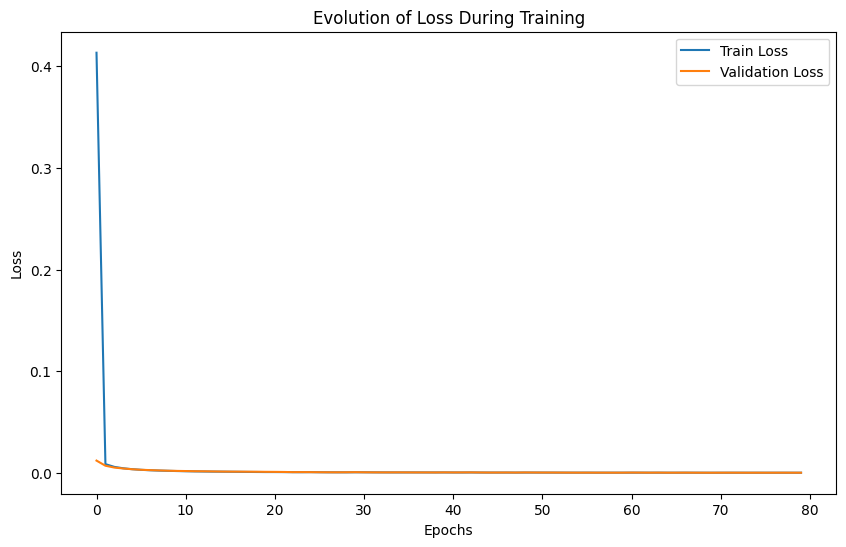

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Đường dẫn đến file log từ mã huấn luyện
log_path = '/content/drive/My Drive/Code-1/Thực tập 1-Dự báo phụ tải/Đề tài/training.log'

# Đọc dữ liệu từ file CSV đã ghi lại
log_data = pd.read_csv(log_path)

# Trích xuất thông tin về loss từ dữ liệu
loss_train = log_data['loss']
loss_val = log_data['val_loss']

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(loss_train, label="Train Loss")
plt.plot(loss_val, label="Validation Loss")
plt.legend()
plt.title("Evolution of Loss During Training")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.layers import Layer, ZeroPadding1D, Concatenate, Add, Conv1D, Activation, Input
from tensorflow.keras import backend as K

# Custom Layer thay thế Lambda(x[:,1:,:])
class Slice(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def call(self, inputs):
        return inputs[:, 1:, :]
    def get_config(self):
        cfg = super().get_config()
        return cfg

def model_wavenet_timeseries(
    len_seq,
    len_out,
    dim_exo,
    dim_target,       # số kênh target
    nb_filters,
    dim_filters,
    dilation_depth,
    use_bias,
    res_l2,
    final_l2,
    batch_size
):
    # Inputs
    input_exo    = Input(shape=(len_seq, dim_exo),    name='input_exo')
    input_target = Input(shape=(len_seq, dim_target), name='input_target')

    exo_inp = input_exo
    tgt_inp = input_target
    outputs = []

    for t in range(len_out):
        p = dim_filters - 1

        # Causal conv exogenous
        pad_exo = ZeroPadding1D((p,0), name=f'pad_exo_{t}')(exo_inp)
        conv_exo= Conv1D(nb_filters, dim_filters, dilation_rate=1,
                         use_bias=use_bias, activation=None,
                         kernel_regularizer=regularizers.l2(res_l2),
                         name=f'causal_conv_exo_{t}')(pad_exo)

        # Causal conv target
        pad_tgt = ZeroPadding1D((p,0), name=f'pad_tgt_{t}')(tgt_inp)
        conv_tgt= Conv1D(nb_filters, dim_filters, dilation_rate=1,
                         use_bias=use_bias, activation=None,
                         kernel_regularizer=regularizers.l2(res_l2),
                         name=f'causal_conv_tgt_{t}')(pad_tgt)

        skip_conns = []

        # Dilated block helper
        def dilated_block(x, out_ch, name):
            pad_amt = 2*(dim_filters-1)
            z = ZeroPadding1D((pad_amt,0), name=f'{name}_pad')(x)
            z = Conv1D(nb_filters, dim_filters, dilation_rate=2,
                       activation='relu', use_bias=use_bias,
                       kernel_regularizer=regularizers.l2(res_l2),
                       name=f'{name}_dilated1')(z)
            skip = Conv1D(out_ch, 1, padding='same', use_bias=False,
                          kernel_regularizer=regularizers.l2(res_l2),
                          name=f'{name}_skip1')(z)
            res  = Conv1D(out_ch, 1, padding='same', use_bias=False,
                          kernel_regularizer=regularizers.l2(res_l2),
                          name=f'{name}_res1')(z)
            return skip, res

        # First dilated block
        skip_e1, res_e1 = dilated_block(conv_exo, dim_exo,    f'exo_{t}')
        skip_t1, res_t1 = dilated_block(conv_tgt, dim_target, f'tgt_{t}')
        skip_conns.append(Concatenate(name=f'skip_cat_{t}')([skip_e1, skip_t1]))

        # Residual adds
        exo_out = Add(name=f'exo_resadd_{t}')([exo_inp, res_e1])
        tgt_out = Add(name=f'tgt_resadd_{t}')([tgt_inp, res_t1])

        # Concat exo & tgt
        x = Concatenate(name=f'exo_tgt_cat_{t}')([exo_out, tgt_out])

        # Further dilated blocks
        for i in range(2, dilation_depth+1):
            pad_amt = (2**i)*(dim_filters-1)
            z = ZeroPadding1D((pad_amt,0), name=f'pad_{i}_{t}')(x)
            z = Conv1D(nb_filters, dim_filters, dilation_rate=2**i,
                       activation='relu', use_bias=use_bias,
                       kernel_regularizer=regularizers.l2(res_l2),
                       name=f'dilated_conv_{i}_{t}')(z)
            skip_i = Conv1D(dim_exo+dim_target, 1, padding='same', use_bias=False,
                            kernel_regularizer=regularizers.l2(res_l2),
                            name=f'skip_{i}_{t}')(z)
            res_i  = Conv1D(dim_exo+dim_target, 1, padding='same', use_bias=False,
                            kernel_regularizer=regularizers.l2(res_l2),
                            name=f'res_{i}_{t}')(z)
            x = Add(name=f'resadd_{i}_{t}')([x, res_i])
            skip_conns.append(skip_i)

        # Sum skip connections
        total = Add(name=f'total_skip_{t}')(skip_conns)
        lin   = Activation('linear', name=f'lin_out_{t}')(total)

        # Output for step t
        out_f = Conv1D(dim_target, 1, padding='same',
                       kernel_regularizer=regularizers.l2(final_l2),
                       name=f'out_f_tgt_{t}')(lin)
        step = Slice(name=f'step_pred_{t}')(out_f)
        outputs.append(step)

        # Update windows for next step
        upd_exo = Conv1D(dim_exo, 1, padding='same',
                         name=f'upd_exo_conv_{t}')(lin)
        exo_inp = Concatenate(axis=1, name=f'upd_exo_{t}')([exo_inp, upd_exo])
        exo_inp = Slice(name=f'upd_exo_slice_{t}')(exo_inp)

        tgt_inp = Concatenate(axis=1, name=f'upd_tgt_{t}')([tgt_inp, step])
        tgt_inp = Slice(name=f'upd_tgt_slice_{t}')(tgt_inp)

    # Stack outputs to shape (batch, len_out, dim_target)
    y_out = Concatenate(axis=1, name='y_out')(outputs)

    return tf.keras.Model([input_exo, input_target], y_out)


In [ ]:
def compute_len_seq(dilation_depth):
  return (2 ** dilation_depth * 2)

nb_filters = 96
dim_filters = 2
dilation_depth = 4     # len_seq = 32
use_bias = True
res_l2 = 0
final_l2 = 0

batch_size = 128
len_out = 48
dim_exo = 6
dim_target = 3

len_seq = compute_len_seq(dilation_depth)
print(len_seq)

model = model_wavenet_timeseries(len_seq, len_out, dim_exo, dim_target, nb_filters, dim_filters, dilation_depth, use_bias, res_l2, final_l2, batch_size)

32


In [ ]:
import tensorflow as tf
import numpy as np


import tensorflow as tf
from keras.layers import Lambda


# ================== CÀI ĐẶT ĐƯỜNG DẪN ==================
checkpoint_path = "/content/drive/My Drive/Code-1/Thực tập 1-Dự báo phụ tải/Đề tài/checkpoints/model_checkpoint.keras"

# ================== TẢI MÔ HÌNH ==================
# Sử dụng strategy scope nếu model được lưu với strategy
# Định nghĩa lại hàm lambda và đảm bảo defaults là tuple
def temporal_pad(x, padding=(4,)):  # Chú ý: padding phải là tuple
    return tf.pad(x, [[0,0], [padding[0], 0], [0,0]])

# Đăng ký custom objects
custom_objects = {
    "TemporalPadding": TemporalPadding,  # Nếu dùng cách 1
    "lambda": Lambda(temporal_pad)      # Hoặc định nghĩa lại hàm lambda
}

try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver.connect()
    strategy = tf.distribute.TPUStrategy(tpu)
except ValueError:
    strategy = tf.distribute.get_strategy()
with strategy.scope():
        model = tf.keras.models.load_model(
        checkpoint_path,
        custom_objects=custom_objects
    )
        print("Đã tải mô hình thành công từ checkpoint")

# ================== CHUẨN BỊ DỮ LIỆU TEST ==================
def create_test_dataset(x_test):
    """Tạo dataset cho dự báo không cần nhãn"""
    dataset = tf.data.Dataset.from_tensor_slices({
        "input_exo": x_test[0],
        "input_target": x_test[1]
    })
    return dataset.batch(batch_size=32, drop_remainder=False)  # Điều chỉnh batch_size theo RAM

# Giả định dữ liệu test có định dạng:
# x_test = (x_test_exo, x_test_target)
# x_test_exo shape: (N, len_seq, 6)
# x_test_target shape: (N, len_seq, 3)
test_dataset = create_test_dataset(x_test)

# ================== THỰC HIỆN DỰ BÁO ==================
predictions = model.predict(test_dataset, verbose=1)

# ================== XỬ LÝ KẾT QUẢ ==================
print("Shape kết quả dự báo:", predictions.shape)
print("Ví dụ kết quả đầu tiên:", predictions[0])

NameError: name 'TemporalPadding' is not defined

In [ ]:
import tensorflow as tf
import os

# ================== CÀI ĐẶT ĐƯỜNG DẪN ==================
checkpoint_dir = "/content/drive/My Drive/Code-1/Thực tập 1-Dự báo phụ tải/Đề tài/checkpoints"
checkpoint_path = os.path.join(checkpoint_dir, "model_checkpoint.keras")

# ================== Khởi tạo strategy (CPU/GPU/TPU) ==================
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver.connect()
    strategy = tf.distribute.TPUStrategy(tpu)
except ValueError:
    gpus = tf.config.list_physical_devices('GPU')
    strategy = tf.distribute.MirroredStrategy() if gpus else tf.distribute.get_strategy()

# ================== Bật unsafe deserialization ==================
tf.keras.config.enable_unsafe_deserialization()

# ================== Tải mô hình và weights ==================
with strategy.scope():
    model = tf.keras.models.load_model(
        checkpoint_path,
        safe_mode=False,   # Cho phép lớp Lambda
        compile=True
    )
    print("Mô hình đã được tải từ:", checkpoint_path)

# Tiếp tục prepare test_dataset và predict như bình thường...

# ================== CHUẨN BỊ DỮ LIỆU (KHÔNG SHUFFLE) ==================
def create_dataset(x_data, y_data):
    """
    x_data[0]: array shape (N, len_seq, 6)  – 6 biến ngoại sinh
    x_data[1]: array shape (N, len_seq, 3)  – 3 biến target
    y_data:    array shape (N, len_out, 3)  – nhãn dự báo
    """
    dataset = tf.data.Dataset.from_tensor_slices((
        {
          "input_exo":   x_data[0],  # full 6 features
          "input_target": x_data[1]  # full 3 features
        },
        y_data
    ))
    return dataset.batch(global_batch_size, drop_remainder=True)

# Tạo dataset cho huấn luyện và validation
test_dataset   = create_dataset(x_test,   y_test)

# ================== DỰ BÁO TRÊN TẬP TEST ==================
predictions = model.predict(test_dataset)

# predictions.shape = (M, len_out, 3)  # theo cấu hình đầu ra
print("Dự báo hoàn tất, kích thước output:", predictions.shape)

# ================== LƯU KẾT QUẢ DỰ BÁO (TÙY CHỌN) ==================
# Ví dụ lưu ra file numpy
# np.save('/content/drive/My Drive/Code-1/Thực tập 1-Dự báo phụ tải/Đề tài/predictions.npy', predictions)


TypeError: <class 'keras.src.models.functional.Functional'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras.src.models.functional', 'class_name': 'Functional', 'config': {}, 'registered_name': 'Functional', 'build_config': {'input_shape': None}, 'compile_config': {'optimizer': {'module': 'keras.optimizers', 'class_name': 'Adam', 'config': {'name': 'adam', 'learning_rate': {'module': 'keras.optimizers.schedules', 'class_name': 'InverseTimeDecay', 'config': {'initial_learning_rate': 0.005, 'decay_steps': 50, 'decay_rate': 0.01, 'staircase': True, 'name': 'InverseTimeDecay'}, 'registered_name': None}, 'weight_decay': None, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'loss_scale_factor': None, 'gradient_accumu

In [ ]:
try:
    # Thử tìm TPU (nếu không có thì sẽ ném ValueError)
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.experimental.TPUStrategy(tpu)
    print("Running on TPU:", tpu.master())
except ValueError:
    # Nếu không tìm thấy TPU, kiểm tra GPU
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        strategy = tf.distribute.get_strategy()  # Nếu có GPU, sử dụng GPU
        print("Running on GPU")
    else:
        strategy = tf.distribute.get_strategy()  # Nếu không có GPU, sử dụng CPU
        print("Running on CPU")

# Bên trong scope của strategy, bạn xây dựng và huấn luyện mô hình của mình:
with strategy.scope():
    pred_train = model.predict((x_train[0],x_train[1]),verbose=1,batch_size=batch_size)
    pred_test = model.predict((x_test[0],x_test[1]),verbose=1,batch_size=batch_size)

Running on GPU
248/248 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


In [ ]:
pred_train.shape

(31744, 18, 3)

In [ ]:
pred_test.shape

(3840, 18, 3)

In [ ]:
# @title Tính R-squared và MAPE
def R_squared(y_true,y_pred):
  tss = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
  rss = tf.reduce_sum(tf.square(y_true - y_pred))
  r2 = 1.0 - rss / tss
  return r2

r2_train = R_squared(y_train, pred_train)
print(f"R-squared on the train dataset: {r2_train.numpy()*100:.2f}%")
r2_test = R_squared(y_test, pred_test)
print(f"R-squared on the test dataset: {r2_test.numpy()*100:.2f}%")

R-squared on the train dataset: 99.62%
R-squared on the test dataset: 99.52%


In [ ]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = tf.cast(y_true, tf.float32), tf.cast(y_pred, tf.float32)
    return tf.reduce_mean(tf.abs((y_true - y_pred) / y_true)) * 100

mape_train = mean_absolute_percentage_error(y_train, pred_train)
print(f"MAPE on the train dataset: {mape_train.numpy():.2f}%")
mape_test = mean_absolute_percentage_error(y_test, pred_test)
print(f"MAPE on the test dataset: {mape_test.numpy():.2f}%")

MAPE on the train dataset: inf%
MAPE on the test dataset: 2.19%


In [ ]:
print("Shape of y_train:", y_train.shape)
print("Shape of pred_train:", pred_train.shape)
print(y_train[0:2,:,:]);print()
print(pred_train[0:2,:,:])

Shape of y_train: (31744, 18, 3)
Shape of pred_train: (31744, 18, 3)
[[[0.27190176 0.22905615 0.13402086]
  [0.27306572 0.20267326 0.14506334]
  [0.27334467 0.20326957 0.14099261]
  [0.25221604 0.15142916 0.15195979]
  [0.2635523  0.15903763 0.15681803]
  [0.2808669  0.16327369 0.16388242]
  [0.26510578 0.15177874 0.14224915]
  [0.24643008 0.1397697  0.13166413]
  [0.21739446 0.16697511 0.11316931]
  [0.20491351 0.14256632 0.14362149]
  [0.20787142 0.11735555 0.16530687]
  [0.21642774 0.12091301 0.2205829 ]
  [0.22897598 0.13438207 0.2195811 ]
  [0.22677319 0.18122558 0.20685361]
  [0.23933591 0.2800329  0.21799454]
  [0.25643408 0.2520255  0.22527319]
  [0.2714689  0.3105696  0.21761234]
  [0.34522915 0.34538352 0.24333952]]

 [[0.27306572 0.20267326 0.14506334]
  [0.27334467 0.20326957 0.14099261]
  [0.25221604 0.15142916 0.15195979]
  [0.2635523  0.15903763 0.15681803]
  [0.2808669  0.16327369 0.16388242]
  [0.26510578 0.15177874 0.14224915]
  [0.24643008 0.1397697  0.13166413]
  [0

In [ ]:
import numpy as np

def reconstruct_original_sequence(data, window_size):
    """
    Khôi phục dữ liệu về dạng chuỗi ban đầu từ data đã window.
    data: np.ndarray shape (num_windows, window_size, n_features)
    window_size: int
    Trả về: np.ndarray shape (window_size + num_windows-1, n_features)
    """
    num_windows, _, n_features = data.shape

    # 1) Lấy toàn bộ window đầu tiên (window_size, n_features)
    original_sequence = data[0]  # shape: (window_size, n_features)

    # 2) Với mỗi window sau, nối thêm hàng cuối (1, n_features)
    for i in range(1, num_windows):
        last_row = data[i, -1:, :]  # shape: (1, n_features)
        original_sequence = np.concatenate([original_sequence, last_row], axis=0)

    return original_sequence

# Ví dụ với y_train và pred_train shape (125696, 18, 3)
y_train_original  = reconstruct_original_sequence(y_train, 18)
pred_train_original = reconstruct_original_sequence(pred_train, 18)

y_test_original   = reconstruct_original_sequence(y_test,  18)
pred_test_original = reconstruct_original_sequence(pred_test, 18)

print("Shape y_train_original: ", y_train_original.shape)   # (125696+?-1, 3)
print("Shape y_test_original:  ", y_test_original.shape)

print("Shape of y_train_original:", y_train_original.shape)
print(y_train_original[:5]);print()
print("Shape of pred_train_original:", pred_train_original.shape);
print(pred_train_original[:5]);print()

print("Shape of y_test_original:", y_test_original.shape)
print(y_test_original[:5]);print()
print("Shape of pred_test_original:", pred_test_original.shape);
print(pred_test_original[:5])


Shape y_train_original:  (31761, 3)
Shape y_test_original:   (3857, 3)
Shape of y_train_original: (31761, 3)
[[0.27190176 0.22905615 0.13402086]
 [0.27306572 0.20267326 0.14506334]
 [0.27334467 0.20326957 0.14099261]
 [0.25221604 0.15142916 0.15195979]
 [0.2635523  0.15903763 0.15681803]]

Shape of pred_train_original: (31761, 3)
[[0.27147564 0.22442602 0.13334712]
 [0.2710726  0.1972442  0.14238198]
 [0.24837473 0.20654975 0.15965024]
 [0.2445575  0.14708583 0.16566688]
 [0.2624989  0.15113528 0.15818186]]

Shape of y_test_original: (3857, 3)
[[0.62294644 0.4967263  0.65290123]
 [0.59096843 0.54417515 0.6877256 ]
 [0.5626962  0.5181063  0.68152016]
 [0.53271306 0.47878549 0.6551377 ]
 [0.50598395 0.43724322 0.6286677 ]]

Shape of pred_test_original: (3857, 3)
[[0.6277652  0.49557966 0.6564152 ]
 [0.5867303  0.5412421  0.687753  ]
 [0.5669974  0.51107675 0.6828184 ]
 [0.52626497 0.47253826 0.66438097]
 [0.50999445 0.43168968 0.6300872 ]]


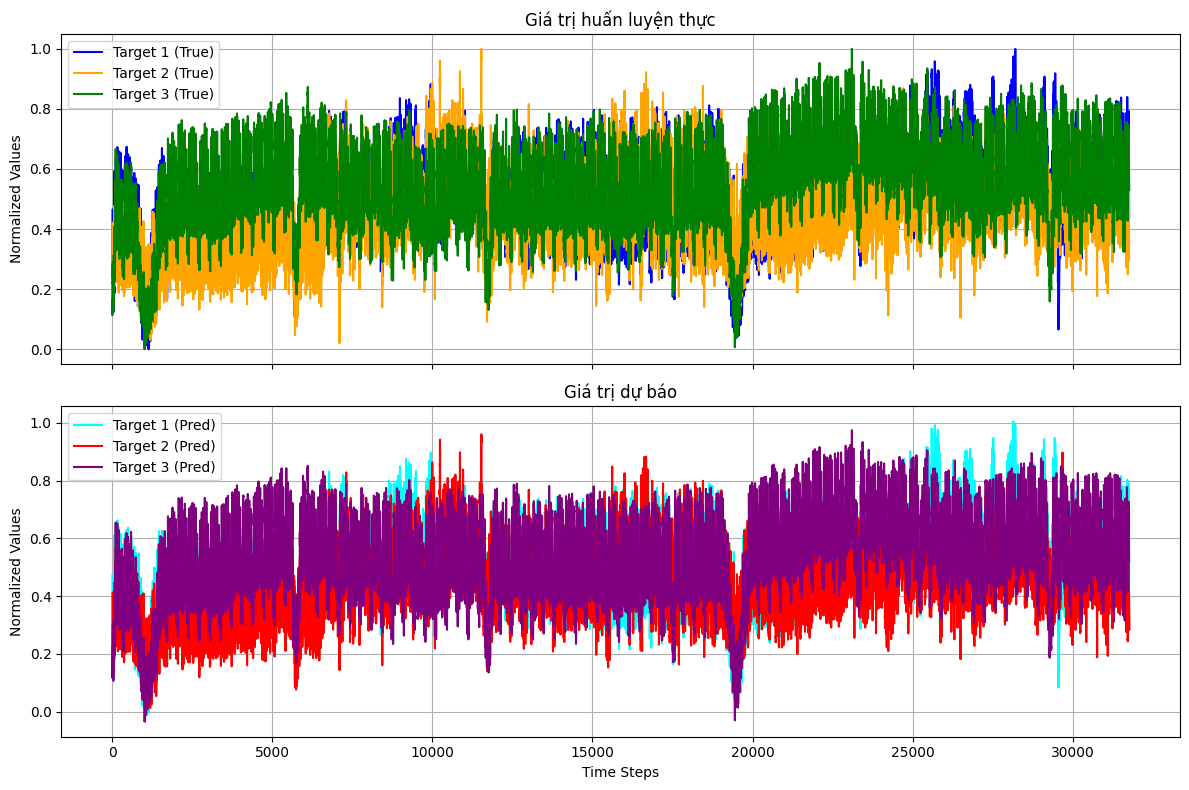

In [ ]:
import matplotlib.pyplot as plt

# Giả sử y_train_original và pred_train_original có shape (T, 3)
colors_true = ['blue', 'orange', 'green']
colors_pred = ['cyan', 'red', 'purple']
labels = ['Target 1', 'Target 2', 'Target 3']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Vẽ y_train_original: 3 cột, 3 màu
for i in range(3):
    ax1.plot(
        y_train_original[:, i],
        label=f'{labels[i]} (True)',
        color=colors_true[i]
    )
ax1.set_title('Giá trị huấn luyện thực')
ax1.set_ylabel('Normalized Values')
ax1.legend()
ax1.grid(True)

# Vẽ pred_train_original
for i in range(3):
    ax2.plot(
        pred_train_original[:, i],
        label=f'{labels[i]} (Pred)',
        color=colors_pred[i]
    )
ax2.set_title('Giá trị dự báo')
ax2.set_xlabel('Time Steps')
ax2.set_ylabel('Normalized Values')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


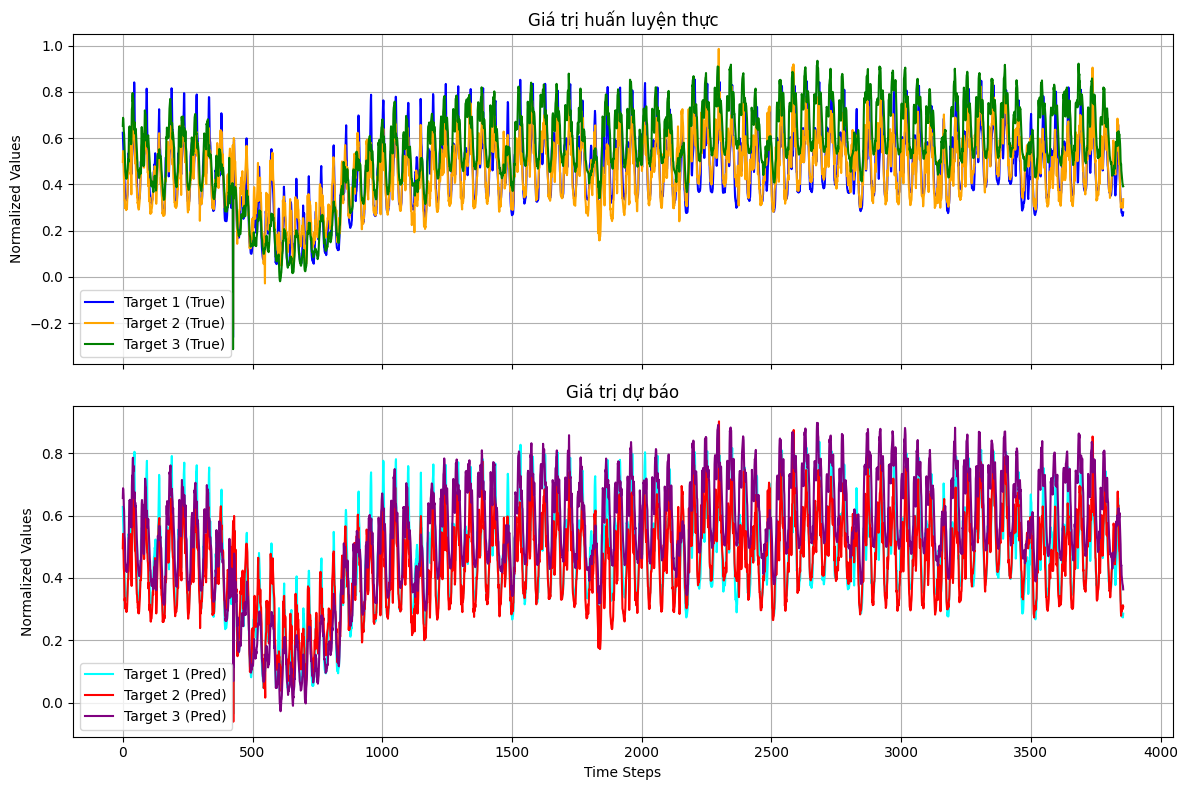

In [ ]:
import matplotlib.pyplot as plt

# Giả sử y_train_original và pred_train_original có shape (T, 3)
colors_true = ['blue', 'orange', 'green']
colors_pred = ['cyan', 'red', 'purple']
labels = ['Target 1', 'Target 2', 'Target 3']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Vẽ y_train_original: 3 cột, 3 màu
for i in range(3):
    ax1.plot(
        y_test_original[:, i],
        label=f'{labels[i]} (True)',
        color=colors_true[i]
    )
ax1.set_title('Giá trị huấn luyện thực')
ax1.set_ylabel('Normalized Values')
ax1.legend()
ax1.grid(True)

# Vẽ pred_train_original
for i in range(3):
    ax2.plot(
        pred_test_original[:, i],
        label=f'{labels[i]} (Pred)',
        color=colors_pred[i]
    )
ax2.set_title('Giá trị dự báo')
ax2.set_xlabel('Time Steps')
ax2.set_ylabel('Normalized Values')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# @title Tính R-squared và MAPE
def R_squared(y_true,y_pred):
  tss = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
  rss = tf.reduce_sum(tf.square(y_true - y_pred))
  r2 = 1.0 - rss / tss
  return r2

r2_train = R_squared(y_train_original, pred_train_original)
print(f"R-squared on the train dataset: {r2_train.numpy()*100:.2f}%")
r2_test = R_squared(y_test_original, pred_test_original)
print(f"R-squared on the test dataset: {r2_test.numpy()*100:.2f}%")

R-squared on the train dataset: 96.39%
R-squared on the test dataset: 96.63%


In [ ]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = tf.cast(y_true, tf.float32), tf.cast(y_pred, tf.float32)
    return tf.reduce_mean(tf.abs((y_true - y_pred) / y_true)) * 100

mape_train = mean_absolute_percentage_error(y_train_original, pred_train_original)
print(f"MAPE on the train dataset: {mape_train.numpy():.2f}%")
mape_test = mean_absolute_percentage_error(y_test_original, pred_test_original)
print(f"MAPE on the test dataset: {mape_test.numpy():.2f}%")

MAPE on the train dataset: inf%
MAPE on the test dataset: 5.32%
